In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import os
from pathlib import Path
os.makedirs('./pdf', exist_ok=True)

# 配置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

# 路径定义
PROCESSED_DIR = Path("../data/processed/")
portions = ["0pc", "10pc", "20pc", "30pc", "40pc", "50pc", "60pc", "70pc", "80pc", "90pc", "100pc"]
main_roads = ['motorway', 'trunk', 'primary', 'secondary']

# 加载元数据
df_raw = pd.read_csv(PROCESSED_DIR / "meta.csv")
# 这里的索引必须和你的 his.npz 里的列顺序完全一致
df_filtered = df_raw[df_raw['highway'].isin(main_roads)].reset_index(drop=True)

📄 已保存至: ./pdf/road_spatial_comparison.pdf


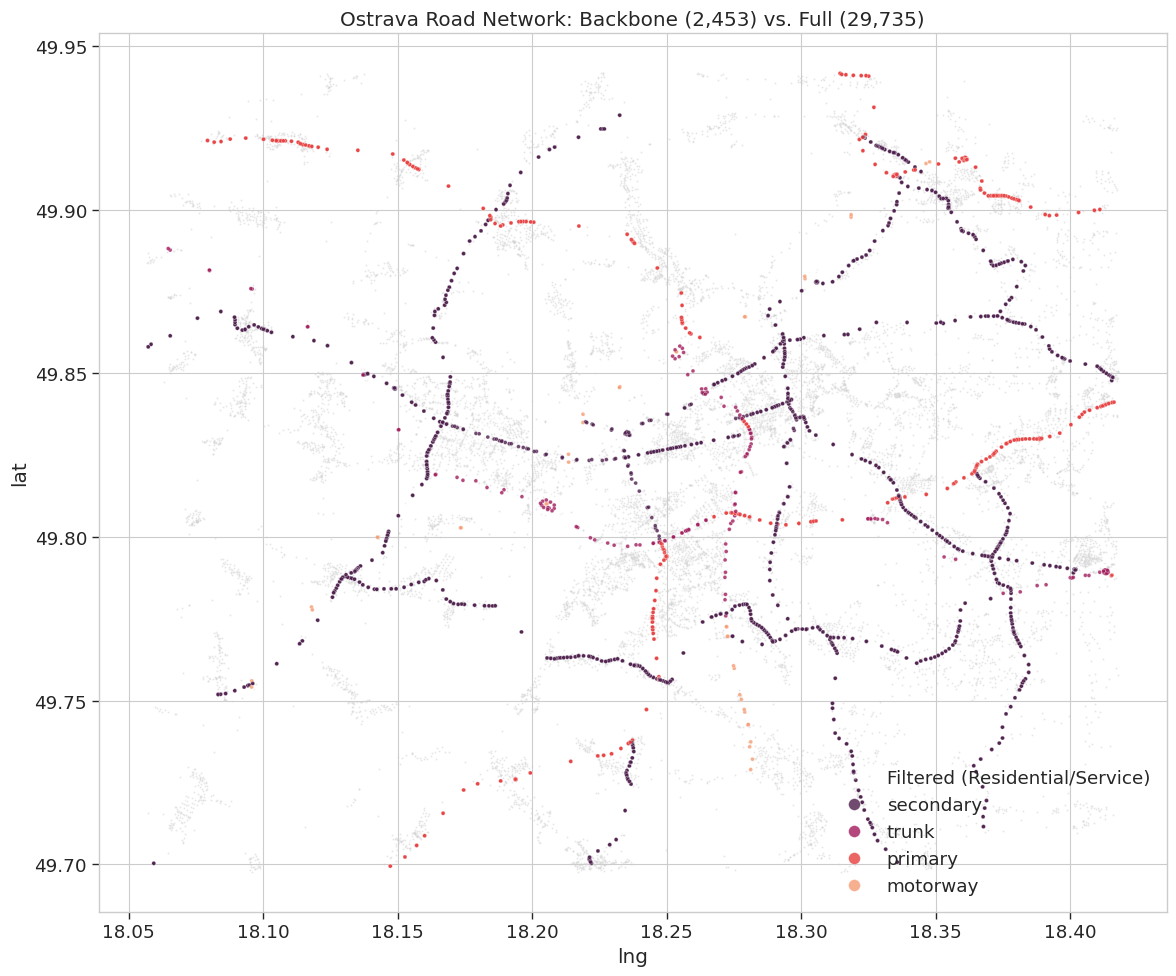

In [2]:
def plot_spatial_comparison(df_raw, df_filtered):
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # 1. 绘制被过滤掉的路段（背景：灰色）
    df_removed = df_raw[~df_raw['highway'].isin(main_roads)]
    ax.scatter(df_removed['lng'], df_removed['lat'], s=0.5, c='lightgray', alpha=0.2, label='Filtered (Residential/Service)')
    
    # 2. 绘制保留的骨干路网（前景：按等级着色）
    sns.scatterplot(data=df_filtered, x='lng', y='lat', hue='highway', 
                    palette='rocket', s=8, alpha=0.8, ax=ax)
    
    ax.set_title("Ostrava Road Network: Backbone (2,453) vs. Full (29,735)")
    ax.legend(markerscale=3, loc='lower right')
    plt.tight_layout()
    # 保存到 pdf 文件夹
    save_path = f"./pdf/road_spatial_comparison.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 已保存至: {save_path}")
    plt.show()

plot_spatial_comparison(df_raw, df_filtered)

📄 已保存至: ./pdf/Distribution_0pc_morning.pdf


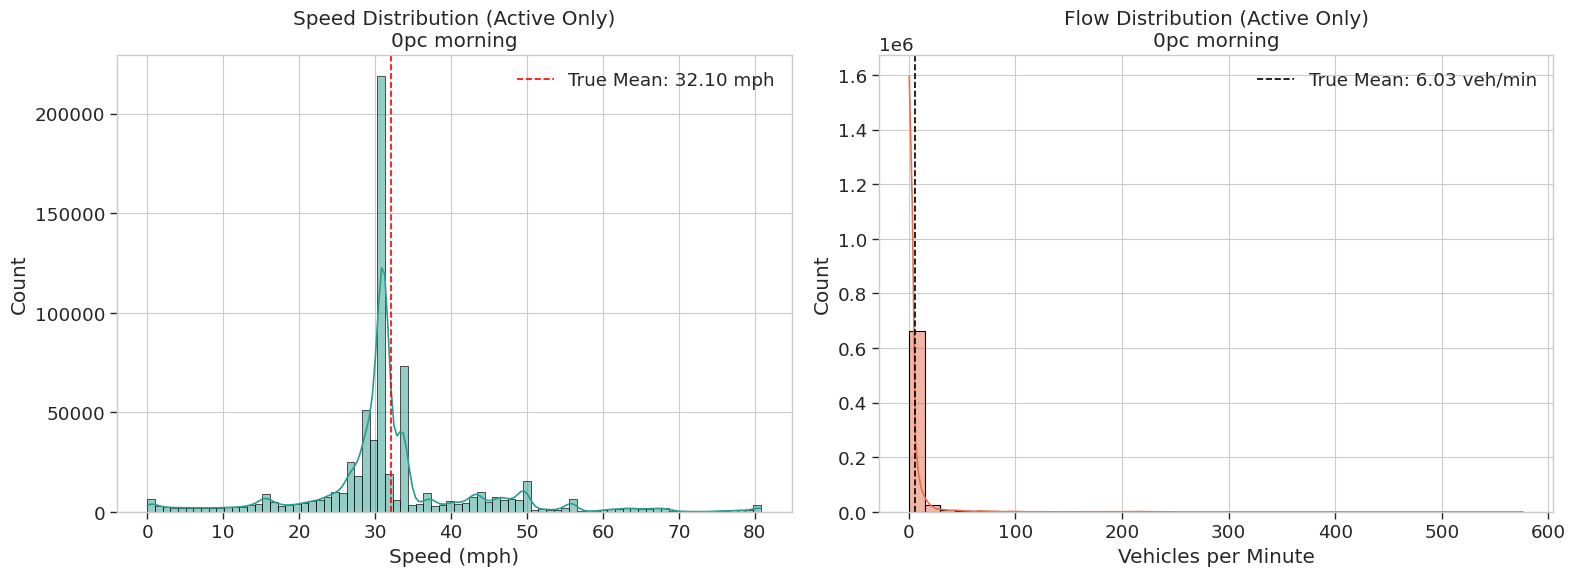

📊 学术统计报告:
实际观测到的平均速度: 32.1022 mph
实际观测到的平均流量: 6.0277 veh/min
📄 已保存至: ./pdf/Distribution_0pc_evening.pdf


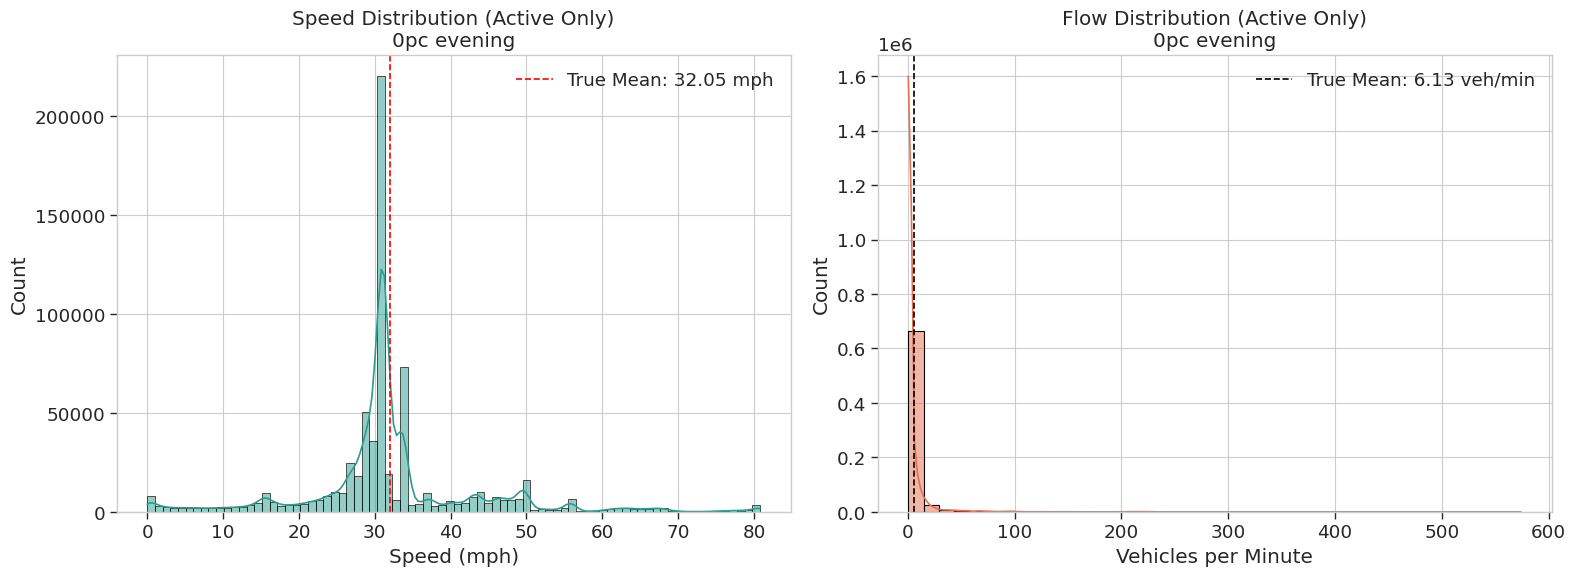

📊 学术统计报告:
实际观测到的平均速度: 32.0476 mph
实际观测到的平均流量: 6.1306 veh/min
📄 已保存至: ./pdf/Distribution_100pc_morning.pdf


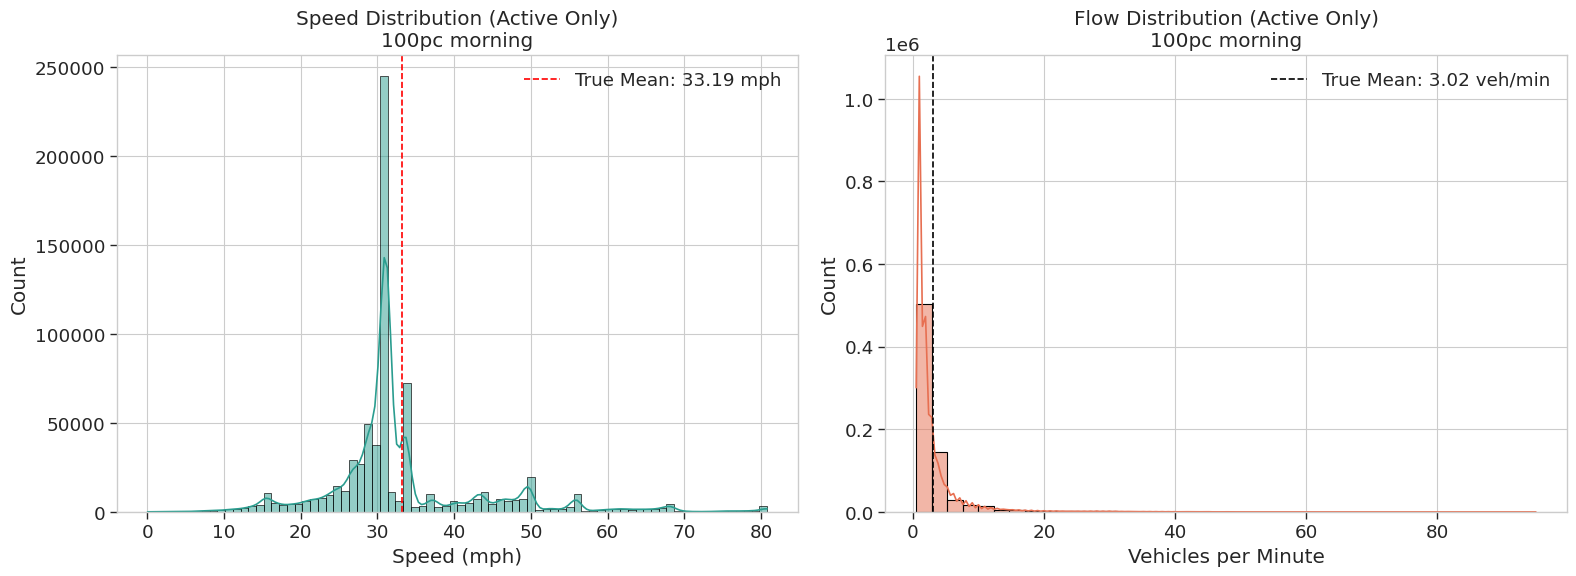

📊 学术统计报告:
实际观测到的平均速度: 33.1934 mph
实际观测到的平均流量: 3.0229 veh/min
📄 已保存至: ./pdf/Distribution_100pc_evening.pdf


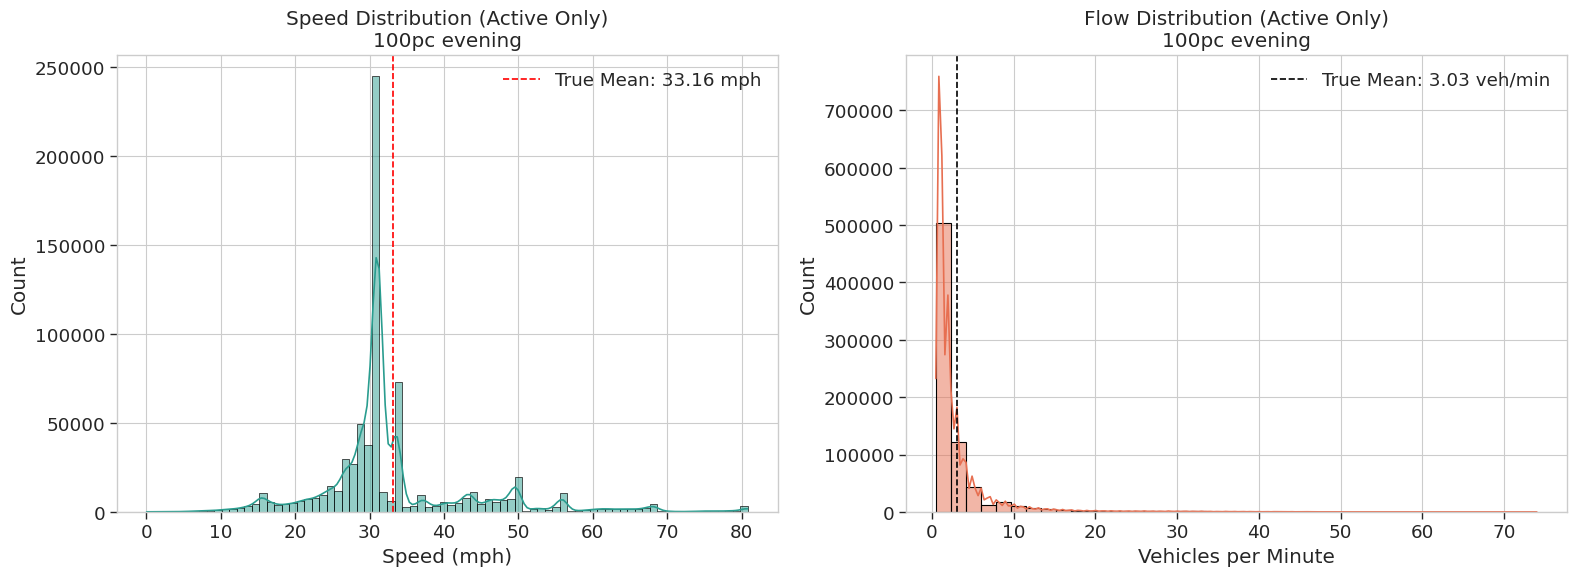

📊 学术统计报告:
实际观测到的平均速度: 33.1642 mph
实际观测到的平均流量: 3.0309 veh/min


In [4]:
def plot_feature_distribution(portion='0pc', period='morning'):
    interval = "10s"
    
    # 根据你 check_h5 的输出路径
    speed_file = f"his_{portion}_{interval}_{period}_speed.h5"
    flow_file = f"his_{portion}_{interval}_{period}_flow.h5"
    
    # 注意：如果文件就在当前目录，直接读取；如果在子目录，用 PROCESSED_DIR / portion / speed_file
    speed_path = PROCESSED_DIR / portion / speed_file
    flow_path = PROCESSED_DIR / portion / flow_file

    df_s = pd.read_hdf(speed_path, key='data')
    df_f = pd.read_hdf(flow_path, key='data')

    # 2. 【核心修改】全量展平并过滤
    # 使用 .values 变成 numpy 数组，效率更高且避免索引干扰
    s_array = df_s.values.flatten()
    f_array = df_f.values.flatten()
    
    # 仅保留大于 0 的有效观测值
    s_active = s_array[s_array > 0]
    f_active = f_array[f_array > 0]

    # 3. 计算真正的学术指标
    true_speed_mean = np.mean(s_active)
    true_flow_mean = np.mean(f_active)

    # 4. 可视化
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- 速度分布 (对标 Figure 2) ---
    sns.histplot(s_active, bins=80, kde=True, ax=axes[0], color='#2a9d8f')
    axes[0].axvline(true_speed_mean, color='red', linestyle='--', 
                    label=f'True Mean: {true_speed_mean:.2f} mph')
    axes[0].set_title(f"Speed Distribution (Active Only)\n{portion} {period}")
    axes[0].set_xlabel("Speed (mph)")
    axes[0].legend()

    # --- 流量分布 ---
    sns.histplot(f_active, bins=40, kde=True, ax=axes[1], color='#e76f51')
    axes[1].axvline(true_flow_mean, color='black', linestyle='--', 
                    label=f'True Mean: {true_flow_mean:.2f} veh/min')
    axes[1].set_title(f"Flow Distribution (Active Only)\n{portion} {period}")
    axes[1].set_xlabel("Vehicles per Minute")
    axes[1].legend()

    plt.tight_layout()
    # 保存到 pdf 文件夹
    save_path = f"./pdf/Distribution_{portion}_{period}.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 已保存至: {save_path}")
    plt.show()

    print(f"📊 学术统计报告:")
    print(f"实际观测到的平均速度: {true_speed_mean:.4f} mph")
    print(f"实际观测到的平均流量: {true_flow_mean:.4f} veh/min")

plot_feature_distribution("0pc", "morning")
plot_feature_distribution("0pc", "evening")
plot_feature_distribution("100pc", "morning")
plot_feature_distribution("100pc", "evening")

📄 已保存至: ./pdf/temporal_traffic_dynamics_0pc_morning.pdf


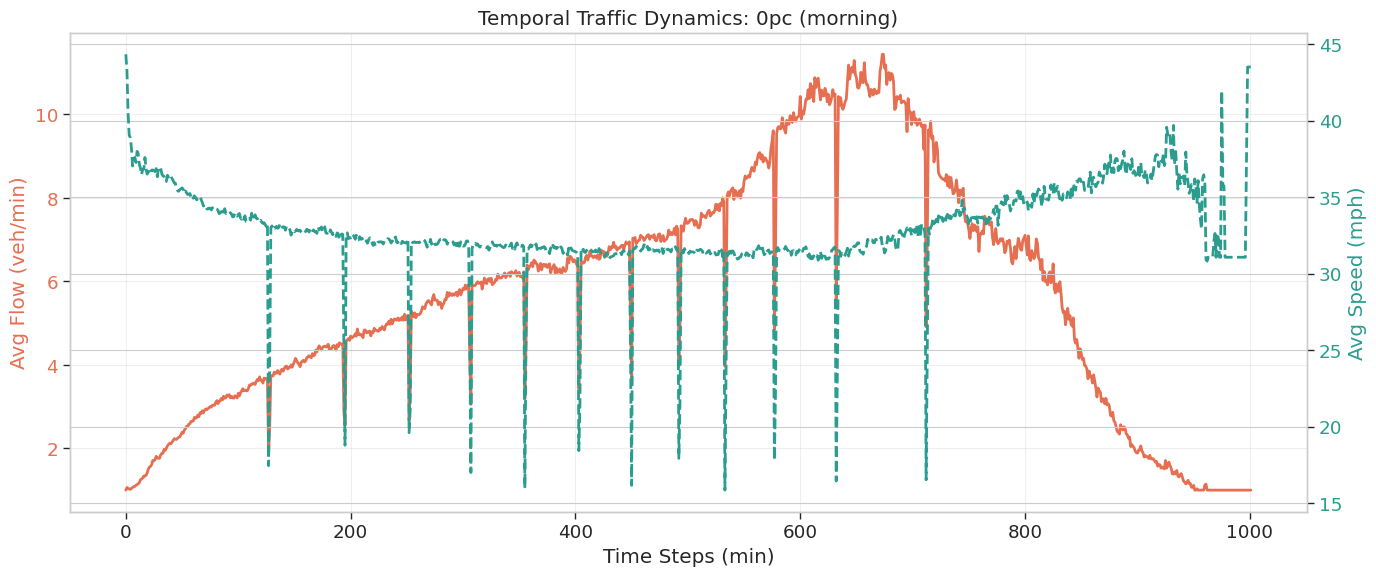

In [6]:
def plot_temporal_dynamics(portion='0pc', period='morning'):
    speed_path = PROCESSED_DIR / portion / f"his_{portion}_10s_{period}_speed.h5"
    flow_path = PROCESSED_DIR / portion / f"his_{portion}_10s_{period}_flow.h5"
    
    df_s = pd.read_hdf(speed_path, key='data')
    df_f = pd.read_hdf(flow_path, key='data')

    # 计算每个时间步的平均值 (只针对活跃路段)
    # 我们用 mask 把 0 替换成 NaN，这样 mean() 会自动忽略它们
    temporal_speed = df_s.replace(0, np.nan).mean(axis=1)
    temporal_flow = df_f.replace(0, np.nan).mean(axis=1)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # 绘制流量随时间变化
    color_f = '#e76f51'
    ax1.set_xlabel('Time Steps (min)')
    ax1.set_ylabel('Avg Flow (veh/min)', color=color_f)
    ax1.plot(temporal_flow.values, color=color_f, linewidth=2, label='Traffic Flow')
    ax1.tick_params(axis='y', labelcolor=color_f)

    # 绘制速度随时间变化 (共用 X 轴)
    ax2 = ax1.twinx()
    color_s = '#2a9d8f'
    ax2.set_ylabel('Avg Speed (mph)', color=color_s)
    ax2.plot(temporal_speed.values, color=color_s, linewidth=2, linestyle='--', label='Traffic Speed')
    ax2.tick_params(axis='y', labelcolor=color_s)

    plt.title(f"Temporal Traffic Dynamics: {portion} ({period})")
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    # 保存到 pdf 文件夹
    save_path = f"./pdf/temporal_traffic_dynamics_{portion}_{period}.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 已保存至: {save_path}")
    plt.show()

plot_temporal_dynamics()

In [7]:
from mpl_toolkits.mplot3d import Axes3D


def plot_3d_road_speed(portion='0pc', period='morning'):
    # 1. 加载元数据 (2.9w 行)
    df_raw = pd.read_csv("../data/processed/meta.csv")
    main_roads = ['motorway', 'trunk', 'primary', 'secondary']
    df_filtered = df_raw[df_raw['highway'].isin(main_roads)].reset_index(drop=True)
    df_removed = df_raw[~df_raw['highway'].isin(main_roads)]

    # 2. 加载速度数据 (2453 路段)
    speed_path = f"../data/processed/{portion}/his_{portion}_1min_{period}_speed.h5"
    df_s = pd.read_hdf(speed_path, key='data')
    
    # 计算每个路段在该时段的平均速度 (排除0)
    avg_speed_per_link = df_s.replace(0, np.nan).mean(axis=0).values

    # 3. 创建 3D 画布
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    # --- 底层：绘制被过滤的灰色背景 (Z 轴设为 0) ---
    ax.scatter(df_removed['lng'], df_removed['lat'], 0, 
               s=1, c='lightgray', alpha=0.1, label='Filtered Roads (Background)')

    # --- 高层：绘制 2453 条路的速度高度图 ---
    # X=经度, Y=纬度, Z=平均速度
    x = df_filtered['lng'].values
    y = df_filtered['lat'].values
    z = avg_speed_per_link

    # 根据速度着色 (使用冷暖色调：红堵绿畅)
    # vmin/vmax 可以根据你的 mph 范围调整，比如 10 到 60
    scatter = ax.scatter(x, y, z, c=z, cmap='RdYlGn', s=15, alpha=0.8, edgecolors='none')

    # 4. 细节修饰
    ax.set_title(f"3D Road Network Speed Profile: {portion} ({period})", fontsize=15)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Average Speed (mph)")
    
    # 设置视角 (调整视角可以看到更好的 3D 效果)
    ax.view_init(elev=30, azim=220) 
    
    # 添加颜色条
    fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Speed (mph)')

    plt.tight_layout()
    # 保存到 pdf 文件夹
    save_path = f"./pdf/3D_Speed_{portion}_{period}.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 已保存至: {save_path}")
    plt.show()

# 运行 0pc 场景的 3D 可视化
plot_3d_road_speed(portion='0pc', period='morning')

FileNotFoundError: File ../data/processed/0pc/his_0pc_1min_morning_speed.h5 does not exist

ValueError: 'c' argument has 29735 elements, which is inconsistent with 'x' and 'y' with size 2453.

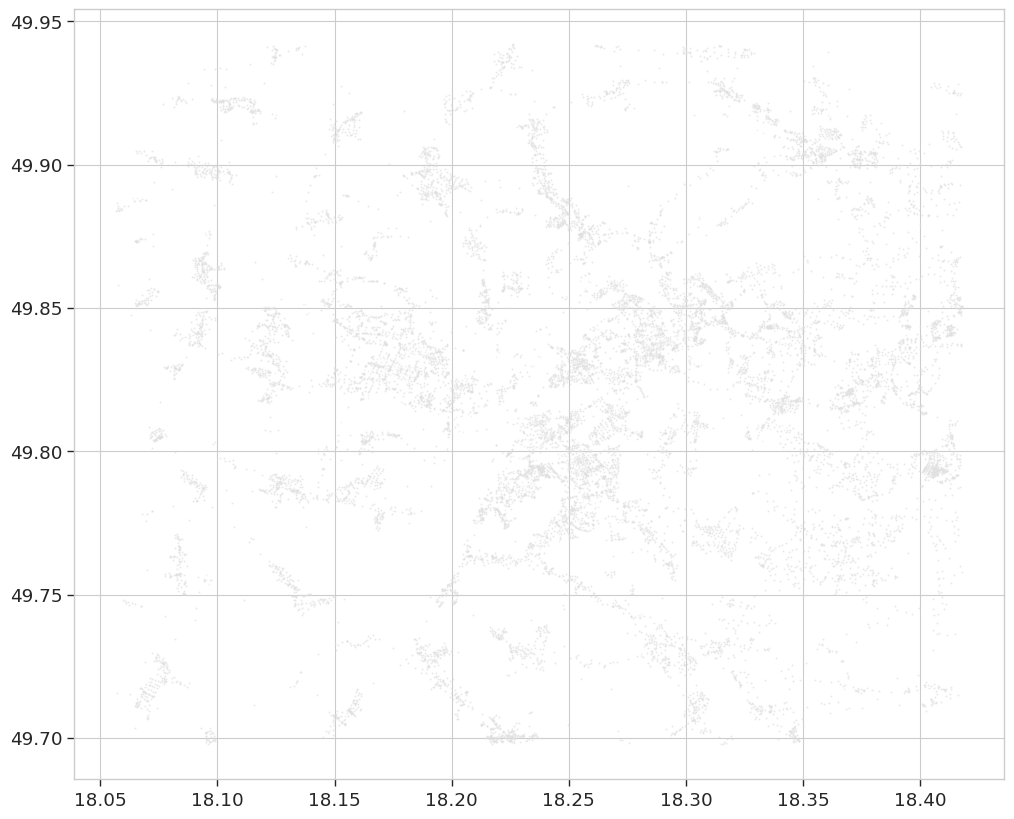

In [6]:
def plot_2d_spatial_speed(portion='0pc', period='morning'):
    # 1. 加载元数据 (用于底色和坐标映射)
    df_raw = pd.read_csv("../data/processed/meta.csv")
    main_roads = ['motorway', 'trunk', 'primary', 'secondary']
    # 保证过滤后的顺序与 H5 数据的 2453 列完全一致
    df_filtered = df_raw[df_raw['highway'].isin(main_roads)].reset_index(drop=True)
    df_removed = df_raw[~df_raw['highway'].isin(main_roads)]

    # 2. 加载 H5 速度数据
    speed_path = PROCESSED_DIR / portion / f"his_{portion}_1min_{period}_speed.h5"
    df_s = pd.read_hdf(speed_path, key='data')
    
    # 计算每个路段在该时段的平均速度 (只统计活跃值)
    # 我们用 .replace(0, np.nan) 确保没车的时候不拉低平均分
    avg_speed = df_s.replace(0, np.nan).mean(axis=0).values

    # 3. 绘图
    plt.figure(figsize=(12, 10))
    
    # 第一层：绘制全城路网背景 (灰色，代表被过滤掉的支路)
    plt.scatter(df_removed['lng'], df_removed['lat'], 
                s=0.5, c='#E0E0E0', alpha=0.3, label='Non-backbone Roads')

    # 第二层：绘制骨干网速度热力图
    # cmap='RdYlGn' 是交通领域的标准：红(低速/堵) -> 黄 -> 绿(高速/畅)
    # vmin, vmax 建议根据你的 mph 数据手动调整，比如 15-55
    scatter = plt.scatter(df_filtered['lng'], df_filtered['lat'], 
                          c=avg_speed, cmap='RdYlGn', s=8, alpha=0.9,
                          vmin=15, vmax=55, label='Backbone Speed (mph)')

    # 4. 美化
    plt.colorbar(scatter, label='Average Speed (mph)', shrink=0.7)
    plt.title(f"Spatial Speed Distribution in Ostrava\nScenario: {portion} | Period: {period}", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    
    # 移除多余的边框，让地图更清爽
    sns.despine(left=True, bottom=True)
    plt.grid(True, linestyle='--', alpha=0.1)
    plt.legend(markerscale=5, loc='lower right')
    
    # 保持坐标比例，防止地图变形
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    # 保存到 pdf 文件夹
    save_path = f"./pdf/2D_Speed_{portion}_{period}.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 已保存至: {save_path}")
    plt.show()

# 运行
plot_2d_spatial_speed('0pc', 'morning')

📄 已保存至: ./pdf/2D_Flow_0pc_morning.pdf


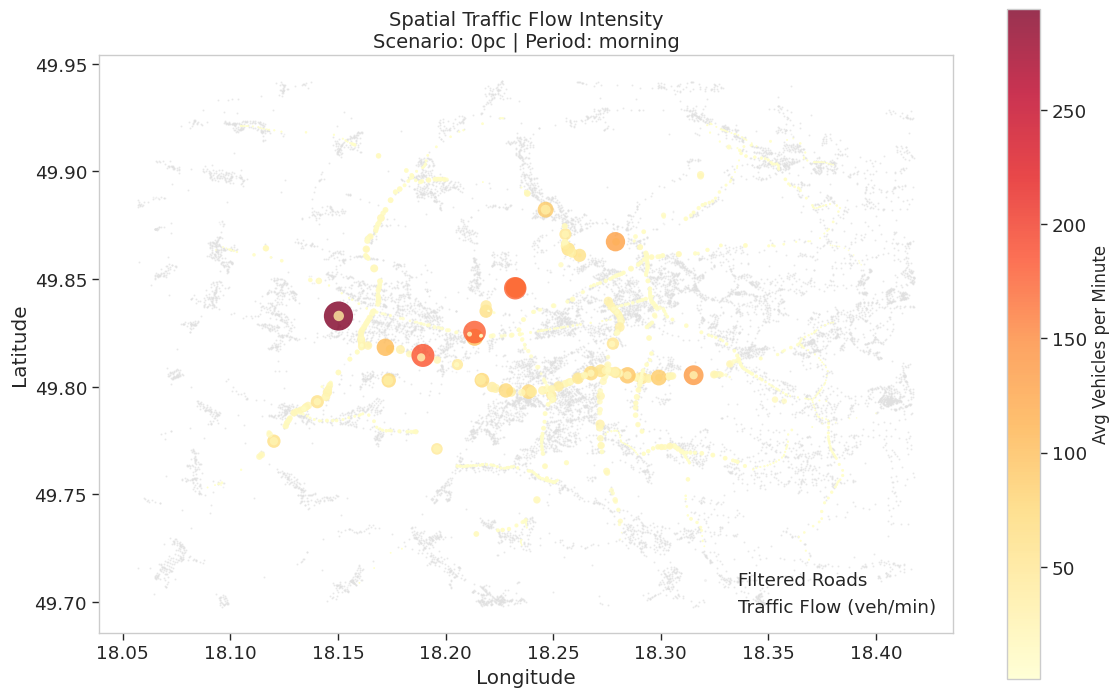

In [7]:
def plot_2d_spatial_flow(portion='0pc', period='morning'):
    # 1. 加载元数据
    df_raw = pd.read_csv("../data/processed/meta.csv")
    main_roads = ['motorway', 'trunk', 'primary', 'secondary']
    df_filtered = df_raw[df_raw['highway'].isin(main_roads)].reset_index(drop=True)
    df_removed = df_raw[~df_raw['highway'].isin(main_roads)]

    # 2. 加载 H5 流量数据 (Volume)
    flow_file = f"his_{portion}_1min_{period}_flow.h5"
    flow_path = PROCESSED_DIR / portion / flow_file
    df_f = pd.read_hdf(flow_path, key='data')
    
    # 计算每个路段的平均活跃流量 (排除0)
    # 流量代表单位时间内经过该路段的唯一车辆数
    avg_flow = df_f.replace(0, np.nan).mean(axis=0).values

    # 3. 绘图
    plt.figure(figsize=(12, 10))
    
    # 第一层：灰色背景 (底图)
    plt.scatter(df_removed['lng'], df_removed['lat'], 
                s=0.5, c='#E0E0E0', alpha=0.3, label='Filtered Roads')

    # 第二层：流量热力图
    # 这里我们使用 'YlOrRd' (黄-橙-红) 颜色，红色代表高流量压力
    # s=avg_flow * 2 让散点大小随流量变化，视觉上更直观
    scatter = plt.scatter(df_filtered['lng'], df_filtered['lat'], 
                          c=avg_flow, s=avg_flow * 1.5, cmap='YlOrRd', 
                          alpha=0.8, edgecolors='none', label='Traffic Flow (veh/min)')

    # 4. 细节优化
    cbar = plt.colorbar(scatter, shrink=0.7)
    cbar.set_label('Avg Vehicles per Minute', fontsize=12)
    
    plt.title(f"Spatial Traffic Flow Intensity\nScenario: {portion} | Period: {period}", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    
    # 保持地理比例
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(markerscale=2, loc='lower right')
    
    # 移除网格线让视觉更聚焦
    plt.grid(False)
    
    plt.tight_layout()
    # 保存到 pdf 文件夹
    save_path = f"./pdf/2D_Flow_{portion}_{period}.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 已保存至: {save_path}")
    plt.show()

# 运行
plot_2d_spatial_flow('0pc', 'morning')

📄 已保存至: ./pdf/scenario_comparison.pdf


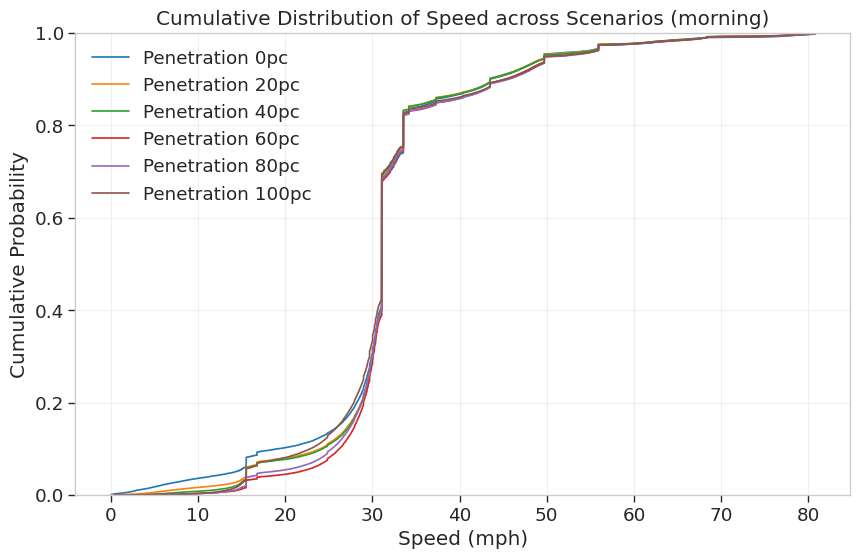

In [8]:
def plot_scenario_comparison(portions=['0pc', '20pc', '40pc', '60pc', '80pc', '100pc'], period='morning'):
    plt.figure(figsize=(10, 6))
    
    for p in portions:
        path = PROCESSED_DIR / p / f"his_{p}_1min_{period}_speed.h5"
        if path.exists():
            df = pd.read_hdf(path, key='data')
            vals = df.values.flatten()
            active_vals = vals[vals > 0]
            
            # 绘制 CDF 曲线
            sns.ecdfplot(active_vals, label=f'Penetration {p}')

    plt.title(f"Cumulative Distribution of Speed across Scenarios ({period})")
    plt.xlabel("Speed (mph)")
    plt.ylabel("Cumulative Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    # 保存到 pdf 文件夹
    save_path = f"./pdf/scenario_comparison.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 已保存至: {save_path}")
    plt.show()

plot_scenario_comparison()